Saving img1.jpg to img1 (1).jpg
Uploaded file: img1 (1).jpg
HOG feature vector length: 6811740


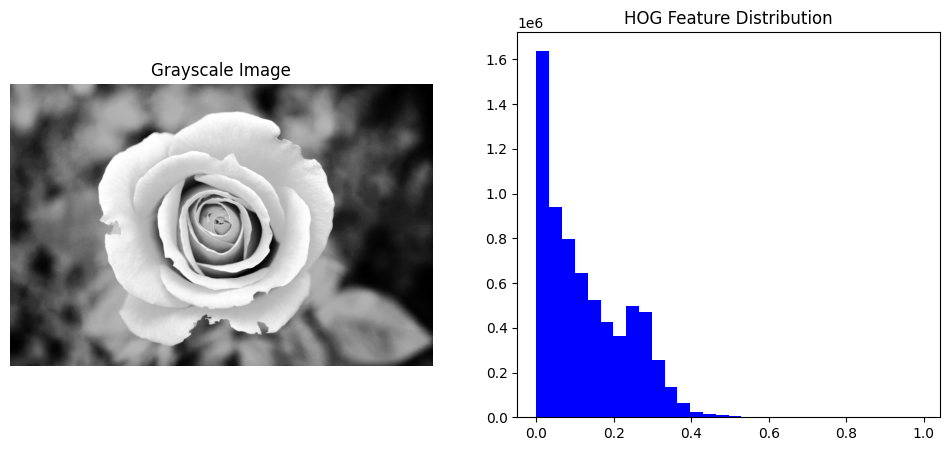

In [3]:
# Step 1: Install OpenCV (if not already available)
!pip install opencv-python opencv-contrib-python matplotlib

# Step 2: Import libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Step 3: Upload your image (make sure it's named img1.jpg or use the filename returned)
uploaded = files.upload()

# Step 4: Read the uploaded image
for fn in uploaded.keys():
    print("Uploaded file:", fn)
    img = cv2.imread(fn)
    if img is None:
        raise ValueError("Image not loaded. Check filename or upload again.")
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 5: Optional normalization to reduce illumination effects
gray = cv2.equalizeHist(gray)

# Step 6: Compute horizontal and vertical gradients
gx = cv2.Sobel(np.float32(gray), cv2.CV_32F, 1, 0, ksize=1)
gy = cv2.Sobel(np.float32(gray), cv2.CV_32F, 0, 1, ksize=1)

# Step 7: Gradient magnitude and orientation
magnitude, angle = cv2.cartToPolar(gx, gy, angleInDegrees=True)

# Step 8: Define HOG parameters
cell_size = (8, 8)   # pixels per cell
block_size = (2, 2)  # cells per block
nbins = 9            # number of orientation bins

hog = cv2.HOGDescriptor(
    _winSize=(gray.shape[1] // cell_size[1] * cell_size[1],
              gray.shape[0] // cell_size[0] * cell_size[0]),
    _blockSize=(block_size[1] * cell_size[1],
                block_size[0] * cell_size[0]),
    _blockStride=(cell_size[1], cell_size[0]),
    _cellSize=(cell_size[1], cell_size[0]),
    _nbins=nbins)

# Step 9: Compute HOG feature vector
hog_features = hog.compute(gray)
print("HOG feature vector length:", len(hog_features))

# Step 10: Visualization
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.hist(hog_features.ravel(), bins=30, color='blue')
plt.title("HOG Feature Distribution")
plt.show()